# Data Visualization using Matplotlib

## Objective

The objective of this project is to transform raw data into meaningful visualizations using Matplotlib. The visualizations are designed to uncover trends, patterns, and insights that support data-driven decision making.

## Research Questions

Before creating visualizations, the following questions are considered:

- How many Movies and TV Shows are available on Netflix?
- How has Netflix content changed over the years?
- Which countries contribute the most content?
- What are the most common content ratings?
- Which genres appear most frequently?
- Which months see the highest content additions?
- What insights can be obtained through visualization?

## Step 1: Import Libraries and Load the Dataset

In this step, the required Python libraries are imported and the Netflix dataset is loaded into a Pandas DataFrame for visualization.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Display first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Step 2: Visualize the Distribution of Content Types

The first visualization compares the number of Movies and TV Shows available on Netflix. This provides a quick overview of the platform's content composition and helps identify which type of content dominates the catalog.

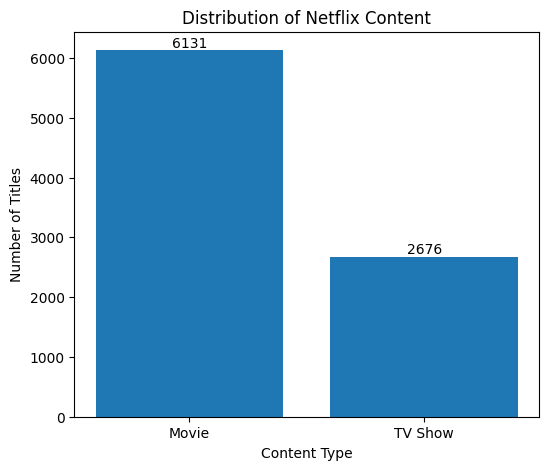

In [4]:
# Count Movies and TV Shows
content_counts = df['type'].value_counts()

# Create bar chart
plt.figure(figsize=(6,5))

plt.bar(content_counts.index,
        content_counts.values)

plt.title("Distribution of Netflix Content")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

# Display values on bars
for i, value in enumerate(content_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.show()

### Observations

- Netflix offers significantly more **Movies** than **TV Shows**.
- The dataset contains **6,131 Movies** and **2,676 TV Shows**.
- Movies account for approximately **70%** of the total content, while TV Shows make up about **30%**.
- This indicates that Netflix's catalog is primarily focused on movies.

### Conclusion

The visualization shows that Movies dominate Netflix's content library. This suggests that Netflix has invested more heavily in movie content than TV Shows, providing users with a wider selection of films.

## Step 3: Visualize Content Released Over the Years

Understanding how content has been released over time helps identify growth trends in Netflix's catalog. This visualization shows the number of titles released each year and highlights periods of rapid content expansion.

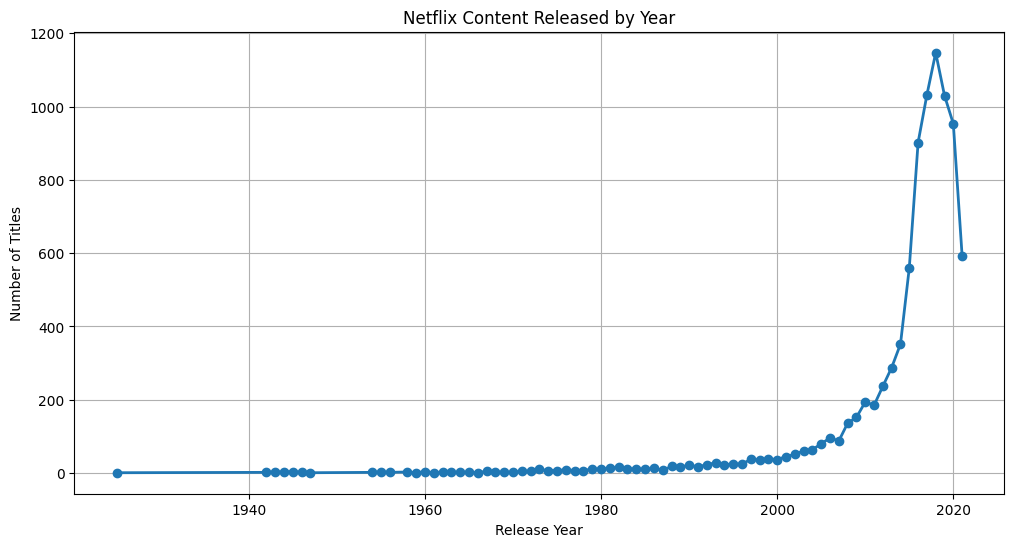

In [5]:
# Count titles by release year
release_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(release_counts.index,
         release_counts.values,
         marker='o',
         linewidth=2)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

### Observations

- Netflix's content releases remained relatively low until the early 2000s.
- From around **2015**, the number of released titles increased rapidly, indicating significant growth in Netflix's content library.
- The highest number of content releases occurred around **2019**, after which the number of releases declined.
- The sharp decline after 2020 may be influenced by the dataset collection period or reduced production during the COVID-19 pandemic.
- Overall, the visualization shows a strong upward trend in Netflix's content production over the last decade.

### Conclusion

Netflix experienced rapid growth in content releases between 2015 and 2019, reflecting a period of significant expansion in its catalog. The decline after 2020 suggests either incomplete data for recent years or external factors affecting content production.

## Step 4: Visualize the Top 10 Countries Producing Netflix Content

This visualization identifies the countries that contribute the most content to Netflix. Understanding the geographic distribution of content helps reveal Netflix's major production markets.

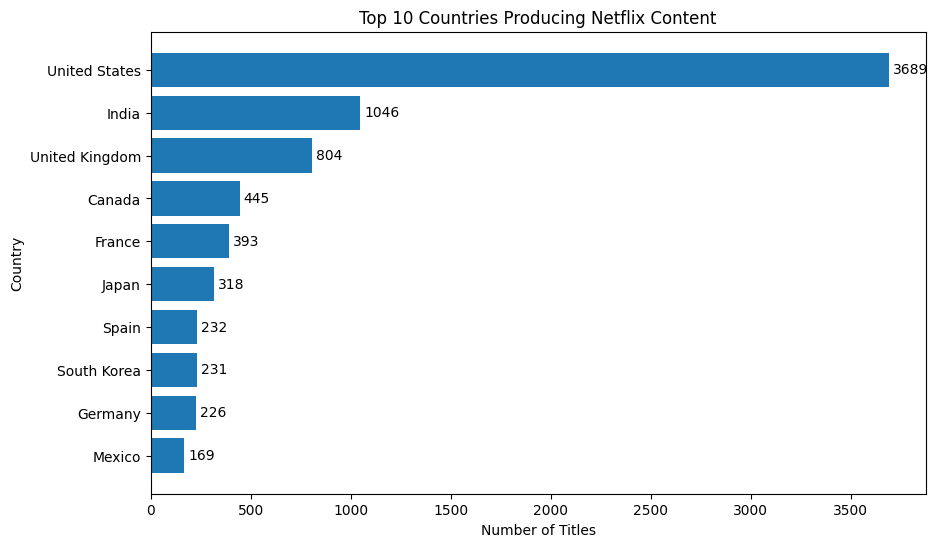

In [6]:
# Split multiple countries and count occurrences
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(country_counts.index, country_counts.values)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

# Display values on bars
for i, value in enumerate(country_counts.values):
    plt.text(value + 20, i, str(value), va='center')

# Highest value at the top
plt.gca().invert_yaxis()

plt.show()

### Observations

- The **United States** is the largest contributor to Netflix's content library with **3,689 titles**, significantly more than any other country.
- **India** is the second-largest contributor with **1,046 titles**, reflecting its strong film and television industry.
- The **United Kingdom** ranks third with **804 titles**.
- Canada, France, Japan, Spain, South Korea, Germany, and Mexico also contribute substantial amounts of content but at much lower levels than the top three countries.
- The distribution indicates that Netflix's content is dominated by a few major production countries while still maintaining a diverse international catalog.

### Conclusion

The visualization highlights that Netflix's content library is primarily driven by productions from the United States, followed by India and the United Kingdom. This demonstrates Netflix's strong presence in major entertainment markets while also showcasing content from various countries around the world.

## Step 5: Visualize the Distribution of Content Ratings

Content ratings indicate the intended audience for Netflix titles. This visualization helps identify which audience categories receive the most content and provides insight into Netflix's target viewers.

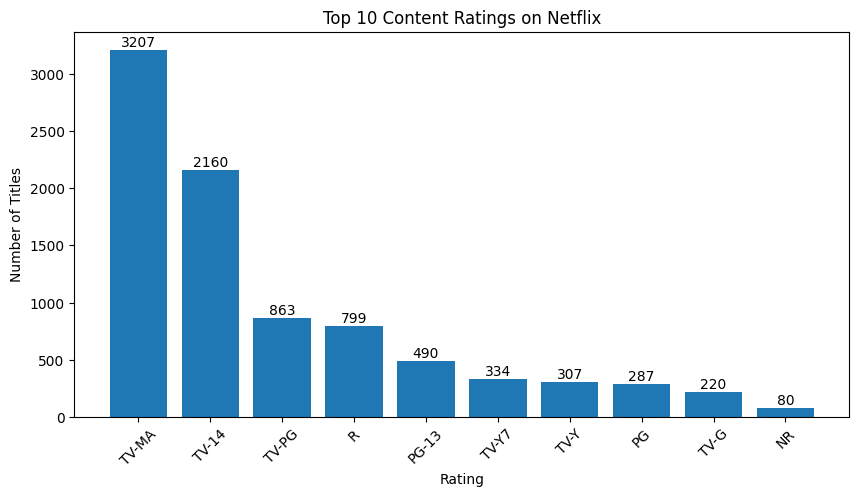

In [7]:
# Count content ratings
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Top 10 Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

# Display values on bars
for i, value in enumerate(rating_counts.values):
    plt.text(i, value + 30, str(value), ha='center')

plt.xticks(rotation=45)

plt.show()

### Observations

- **TV-MA** is the most common content rating on Netflix, with **3,207 titles**, indicating a strong focus on mature audiences.
- **TV-14** is the second most frequent rating with **2,160 titles**, suggesting a significant amount of content suitable for teenagers and older viewers.
- Ratings such as **TV-PG**, **R**, and **PG-13** also have a considerable number of titles.
- Family-friendly ratings like **TV-G** and **PG** are less common compared to mature content.
- The **NR (Not Rated)** category has the fewest titles among the top ten ratings.

### Conclusion

The visualization indicates that Netflix primarily focuses on producing and distributing content for mature and teenage audiences. While family-friendly content is available, the platform's catalog is dominated by titles intended for older viewers.

## Step 6: Visualize the Top 10 Content Genres

Genres represent the type of content available on Netflix. This visualization identifies the most common genres and provides insight into the platform's content preferences.

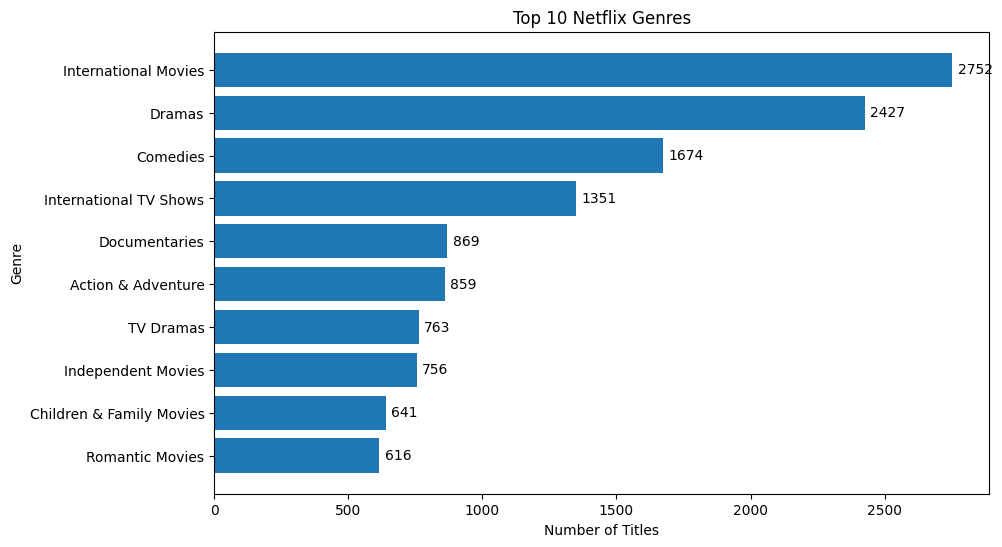

In [8]:
# Split multiple genres and count occurrences
genre_counts = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(genre_counts.index, genre_counts.values)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

# Display values on bars
for i, value in enumerate(genre_counts.values):
    plt.text(value + 20, i, str(value), va='center')

# Highest value at the top
plt.gca().invert_yaxis()

plt.show()

### Observations

- **International Movies** is the most common genre on Netflix with **2,752 titles**, indicating a strong emphasis on global film content.
- **Dramas** rank second with **2,427 titles**, making drama one of the platform's most popular genres.
- **Comedies** are the third most common genre with **1,674 titles**, showing a strong demand for entertaining content.
- **International TV Shows** also have a significant presence with **1,351 titles**, reflecting Netflix's investment in international television programming.
- Genres such as **Documentaries**, **Action & Adventure**, **TV Dramas**, **Independent Movies**, **Children & Family Movies**, and **Romantic Movies** contribute to the platform's diverse content library.

### Conclusion

Netflix offers a diverse collection of genres, with a strong emphasis on International Movies, Dramas, and Comedies. The platform balances globally produced entertainment with a wide variety of content categories to appeal to different audience preferences.

## Step 7: Visualize Movie Duration Distribution

Analyzing movie durations helps understand the typical length of films available on Netflix. A histogram is used to examine the distribution of movie lengths and identify common viewing durations.

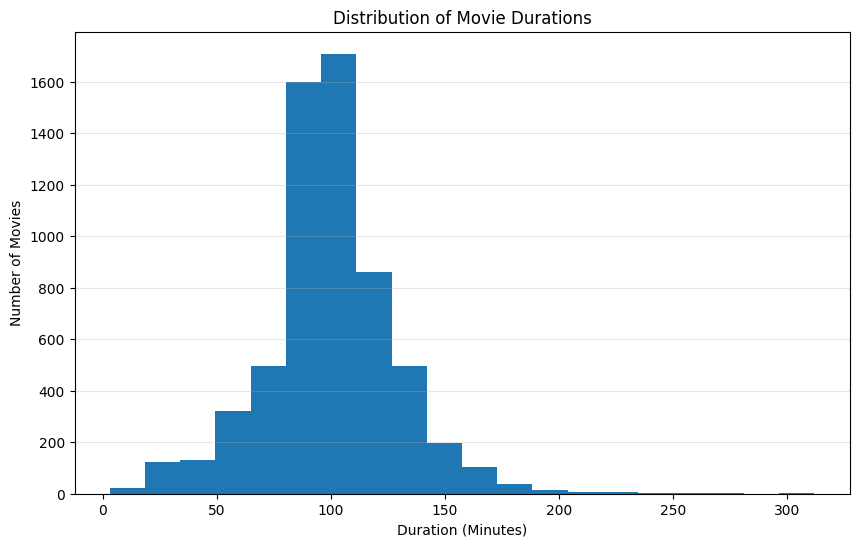

In [10]:
# Filter only movies
movies = df[df['type'] == 'Movie'].copy()

# Remove rows where duration is missing
movies = movies.dropna(subset=['duration'])

# Extract duration in minutes
movies['duration_minutes'] = (
    movies['duration']
    .str.replace(' min', '', regex=False)
    .astype(int)
)

# Plot histogram
plt.figure(figsize=(10,6))

plt.hist(movies['duration_minutes'], bins=20)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.grid(axis='y', alpha=0.3)

plt.show()

### Observations

- Most Netflix movies have durations between **80 and 120 minutes**.
- The distribution is approximately bell-shaped with a slight right skew.
- The highest concentration of movies is around **90 to 100 minutes**, indicating that this is the typical movie length.
- Very short movies (less than 40 minutes) and very long movies (over 180 minutes) are relatively uncommon.
- A few movies have exceptionally long durations, representing potential outliers.

### Conclusion

The majority of Netflix movies have a runtime of approximately 90–100 minutes, suggesting that feature-length films dominate the platform's movie catalog. Extremely short and very long movies are comparatively rare.

## Step 8: Visualize Monthly Content Additions

This visualization examines the months in which Netflix adds the most content to its platform. Understanding monthly trends can provide insights into content release strategies and seasonal patterns.

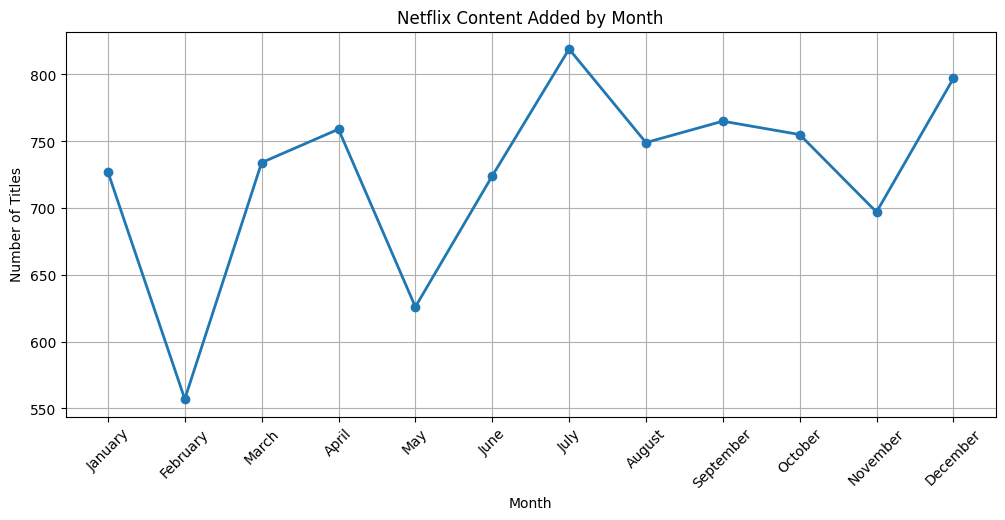

In [11]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Count titles added by month
month_counts = (
    df['date_added']
    .dt.month_name()
    .value_counts()
    .reindex([
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ])
)

plt.figure(figsize=(12,5))

plt.plot(month_counts.index,
         month_counts.values,
         marker='o',
         linewidth=2)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observations

- Netflix adds content throughout the year, but the number of additions varies by month.
- **July** has the highest number of content additions, with over **800 titles**.
- **December** and **September** also show relatively high numbers of new titles.
- **February** has the fewest content additions, making it the least active month.
- Overall, the monthly distribution suggests that Netflix follows a fairly consistent release schedule, with increased activity during certain months.

### Conclusion

The monthly trend indicates that Netflix strategically releases more content during specific periods of the year, particularly in July and December. These periods may coincide with higher viewer engagement and seasonal demand.

## Step 9: Visualize the Top 10 Directors on Netflix

Directors play an important role in content production. This visualization identifies the directors with the highest number of titles available on Netflix, highlighting the most frequent contributors to the platform.

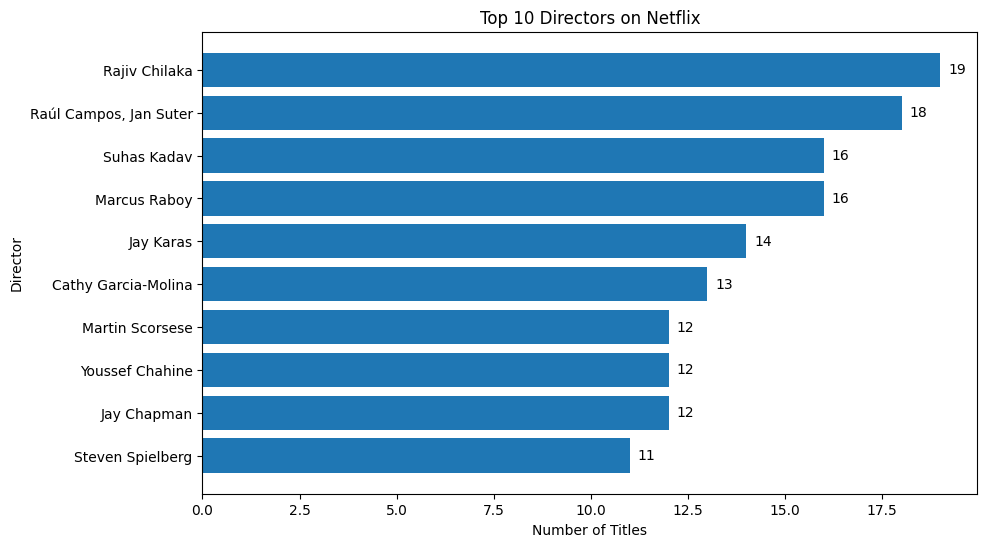

In [12]:
# Count top directors
director_counts = (
    df['director']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(director_counts.index, director_counts.values)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

# Display values on bars
for i, value in enumerate(director_counts.values):
    plt.text(value + 0.2, i, str(value), va='center')

# Highest value at the top
plt.gca().invert_yaxis()

plt.show()

### Observations

- **Rajiv Chilaka** has the highest number of titles on Netflix with **19 titles**.
- **Raúl Campos and Jan Suter** jointly contribute **18 titles**, making them the second most represented directors.
- **Suhas Kadav** and **Marcus Raboy** each have **16 titles**.
- Renowned directors such as **Martin Scorsese** and **Steven Spielberg** also appear among the top contributors.
- The distribution shows that while Netflix collaborates with many directors, a small group contributes a relatively larger number of titles.

### Conclusion

The visualization highlights the directors who have contributed the most content to Netflix. While the platform features work from thousands of filmmakers, a few directors have consistently produced multiple titles, reflecting strong collaborations with Netflix.

# Key Insights

The visualizations reveal several important insights about Netflix's content library:

- Movies account for the majority of Netflix's catalog, significantly outnumbering TV Shows.
- Netflix experienced rapid content growth between 2015 and 2019.
- The United States is the largest contributor of Netflix content, followed by India and the United Kingdom.
- Most Netflix content is targeted toward mature audiences, with TV-MA being the most common rating.
- International Movies and Dramas are the most frequently available genres.
- Most movies have durations between 80 and 120 minutes.
- Content additions occur throughout the year, with July recording the highest number of additions.
- Several directors have established strong partnerships with Netflix by contributing multiple titles.

# Overall Conclusion

This project transformed raw Netflix data into meaningful visualizations using Matplotlib. Through a series of charts, trends and patterns related to content type, release years, countries, ratings, genres, movie durations, monthly additions, and directors were explored.

The visualizations demonstrate that Netflix has experienced substantial growth over recent years while maintaining a diverse global content library. Movies dominate the platform, mature audiences are the primary target, and international content plays a significant role in Netflix's success.

Overall, the project illustrates how effective data visualization can simplify complex datasets, reveal valuable insights, and support informed decision-making.